# Support Vector Machine (SVM) — Phiên bản nâng cấp

**Thuật toán:** Linear SVM, Soft-Margin, tối ưu bằng **Mini-batch SGD + Hinge Loss**

> **Các fix & cải tiến so với phiên bản cũ:**
> - 🔴 **Sửa bug shape mismatch**: `compute_numeric_features` ở demo trả về 16 features nhưng model chỉ train với số features thực tế → load `NUMERIC_FEATURES` + `scaler` từ file pkl giống LR
> - 🔴 **Sửa `np.trapezoid`**: hàm này không tồn tại trong NumPy < 2.0, đổi sang `np.trapz`
> - ✅ **Mini-batch SGD** thay vì pure SGD từng sample → nhanh hơn ~10–50x, gradient ổn định hơn
> - ✅ **Early Stopping + Validation Loss** theo dõi — tránh overfitting
> - ✅ **Threshold tuning trên Validation Set** (dịch chuyển decision boundary thay vì cố định tại 0)
> - ✅ **Loss curve** bỏ ticks dày khi epoch nhiều, thêm val loss


### Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split

cwd = Path.cwd()
DATA_DIR = cwd / '..' / 'data'
if not DATA_DIR.exists():
    DATA_DIR = cwd / 'Labs' / 'Lab1' / 'data'
DATA_DIR = DATA_DIR.resolve()
print(f'Import xong! | DATA_DIR: {DATA_DIR}')


Import xong! | DATA_DIR: C:\Users\hary0\Documents\ML_Group6\ML_Group6\Labs\Lab1\data


## 1. Load dữ liệu

In [2]:
X_all  = load_npz(DATA_DIR / 'X_train.npz').toarray().astype(np.float32)
X_test = load_npz(DATA_DIR / 'X_test.npz').toarray().astype(np.float32)
y_all  = np.load(DATA_DIR / 'y_train.npy').astype(np.float32)
y_test = np.load(DATA_DIR / 'y_test.npy').astype(np.float32)

# ✅ Tách validation set để tuning threshold & early stopping
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)

print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')
print(f'y_train — ham: {int((y_train==0).sum())}  spam: {int((y_train==1).sum())}')
print(f'y_test  — ham: {int((y_test==0).sum())}  spam: {int((y_test==1).sum())}')


X_train: (3401, 3008) | X_val: (601, 3008) | X_test: (880, 3008)
y_train — ham: 1700  spam: 1701
y_test  — ham: 500  spam: 380


## 2. Class SVM_group6 — Nâng cấp

**Thay đổi so với phiên bản cũ:**
- **Mini-batch SGD** (thay vì pure SGD từng sample): ổn định hơn, nhanh hơn ~10–50x
- **Early Stopping**: dừng khi val loss không cải thiện sau `patience` epochs
- **LR Decay**: giảm learning rate dần theo epoch


In [3]:
class SVM_group6:
    """
    Linear SVM tự implement — không dùng ML library.
    Tối ưu: Mini-batch SGD + Hinge Loss + L2 reg + Early Stopping.
    """

    def __init__(self, learning_rate=0.01, n_epochs=100, batch_size=64,
                 lambda_param=0.001, patience=10, lr_decay=0.98, random_state=42):
        """
        Parameters
        ----------
        learning_rate : float  — learning rate ban đầu
        n_epochs      : int    — số epoch tối đa
        batch_size    : int    — ✅ MỚI: mini-batch size (thay vì từng sample)
        lambda_param  : float  — hệ số L2 regularization
        patience      : int    — ✅ MỚI: dừng sớm nếu val loss không cải thiện
        lr_decay      : float  — ✅ MỚI: giảm LR mỗi epoch
        random_state  : int
        """
        self.lr           = learning_rate
        self.n_epochs     = n_epochs
        self.batch_size   = batch_size
        self.lambda_param = lambda_param
        self.patience     = patience
        self.lr_decay     = lr_decay
        self.random_state = random_state
        self.weights      = None
        self.bias         = 0.0
        self.loss_history     = []
        self.val_loss_history = []

    def _to_bipolar(self, y):
        """Chuyển nhãn 0/1 → -1/+1 (SVM chuẩn dùng bipolar)."""
        return np.where(y == 1, 1.0, -1.0)

    def _hinge_loss(self, X, y_bipolar):
        """L = (λ/2)||w||² + (1/N)·Σmax(0, 1 − y'·(w^T x + b))"""
        margins = y_bipolar * (X @ self.weights + self.bias)
        hinge   = np.maximum(0, 1 - margins)
        reg     = (self.lambda_param / 2) * np.dot(self.weights, self.weights)
        return float(reg + np.mean(hinge))

    def fit(self, X, y, X_val=None, y_val=None):
        """
        Huấn luyện bằng Mini-batch SGD.
        Tại sao mini-batch thay vì pure SGD?
        - Pure SGD (1 sample/lần) trên dữ liệu TF-IDF ~3000 chiều rất nhiễu
        - Mini-batch trung bình hoá gradient → ổn định, hội tụ nhanh hơn
        """
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        # ✅ Random init nhỏ thay vì toàn 0
        self.weights = np.random.randn(n_features).astype(np.float64) * 0.01
        self.bias    = 0.0
        self.loss_history     = []
        self.val_loss_history = []

        y_bi = self._to_bipolar(y)
        y_val_bi = self._to_bipolar(y_val) if y_val is not None else None

        best_val_loss  = np.inf
        patience_count = 0
        best_weights   = self.weights.copy()
        best_bias      = self.bias
        current_lr     = self.lr

        for epoch in range(self.n_epochs):
            # Shuffle
            idx  = np.random.permutation(n_samples)
            X_s  = X[idx];  y_s = y_bi[idx]

            # ✅ Mini-batch update
            for start in range(0, n_samples, self.batch_size):
                Xb = X_s[start:start+self.batch_size]
                yb = y_s[start:start+self.batch_size]
                m  = len(yb)

                margins = yb * (Xb @ self.weights + self.bias)  # (batch,)
                mask    = (margins < 1).astype(np.float64)       # vi phạm margin

                # Gradient trung bình trên batch
                grad_w = self.lambda_param * self.weights - (Xb.T @ (mask * yb)) / m
                grad_b = -np.mean(mask * yb)

                self.weights -= current_lr * grad_w
                self.bias    -= current_lr * grad_b

            # ✅ LR Decay
            current_lr *= self.lr_decay

            # Train loss
            train_loss = self._hinge_loss(X, y_bi)
            self.loss_history.append(train_loss)

            # Val loss + early stopping
            if X_val is not None:
                val_loss = self._hinge_loss(X_val, y_val_bi)
                self.val_loss_history.append(val_loss)

                if val_loss < best_val_loss - 1e-5:
                    best_val_loss  = val_loss
                    best_weights   = self.weights.copy()
                    best_bias      = self.bias
                    patience_count = 0
                    status = '  ⭐ best'
                else:
                    patience_count += 1
                    status = f'  (patience {patience_count}/{self.patience})'

                print(f'Epoch {epoch+1:>3}/{self.n_epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{status}')

                if patience_count >= self.patience:
                    print(f'\n⏹ Early stopping tại epoch {epoch+1}! Restore best weights.')
                    self.weights = best_weights
                    self.bias    = best_bias
                    break
            else:
                print(f'Epoch {epoch+1:>3}/{self.n_epochs} | Loss: {train_loss:.4f}')

        print('\n✅ Train xong!')
        return self

    def decision_function(self, X):
        """Score thô: w^T x + b. Dương → spam, âm → ham."""
        return X @ self.weights + self.bias

    def predict(self, X, threshold=0.0):
        """Dự đoán nhãn. threshold mặc định = 0 (decision boundary)."""
        return (self.decision_function(X) >= threshold).astype(int)


print('✅ Định nghĩa class SVM_group6 xong!')


✅ Định nghĩa class SVM_group6 xong!


## 3. Huấn luyện model

In [4]:
model = SVM_group6(
    learning_rate = 0.01,
    n_epochs      = 150,
    batch_size    = 64,
    lambda_param  = 0.001,
    patience      = 15,
    lr_decay      = 0.98,
    random_state  = 42
)

model.fit(X_train, y_train, X_val=X_val, y_val=y_val)


Epoch   1/150 | Train: 0.6437 | Val: 0.6214  ⭐ best
Epoch   2/150 | Train: 0.4758 | Val: 0.4416  ⭐ best
Epoch   3/150 | Train: 0.4022 | Val: 0.3669  ⭐ best
Epoch   4/150 | Train: 0.3734 | Val: 0.3379  ⭐ best
Epoch   5/150 | Train: 0.3580 | Val: 0.3224  ⭐ best
Epoch   6/150 | Train: 0.3466 | Val: 0.3107  ⭐ best
Epoch   7/150 | Train: 0.3372 | Val: 0.3016  ⭐ best
Epoch   8/150 | Train: 0.3293 | Val: 0.2940  ⭐ best
Epoch   9/150 | Train: 0.3222 | Val: 0.2875  ⭐ best
Epoch  10/150 | Train: 0.3159 | Val: 0.2815  ⭐ best
Epoch  11/150 | Train: 0.3105 | Val: 0.2763  ⭐ best
Epoch  12/150 | Train: 0.3055 | Val: 0.2717  ⭐ best
Epoch  13/150 | Train: 0.3009 | Val: 0.2676  ⭐ best
Epoch  14/150 | Train: 0.2965 | Val: 0.2639  ⭐ best
Epoch  15/150 | Train: 0.2923 | Val: 0.2604  ⭐ best
Epoch  16/150 | Train: 0.2886 | Val: 0.2572  ⭐ best
Epoch  17/150 | Train: 0.2853 | Val: 0.2542  ⭐ best
Epoch  18/150 | Train: 0.2821 | Val: 0.2515  ⭐ best
Epoch  19/150 | Train: 0.2792 | Val: 0.2490  ⭐ best
Epoch  20/15

## 4. Loss Curve (Train + Validation)

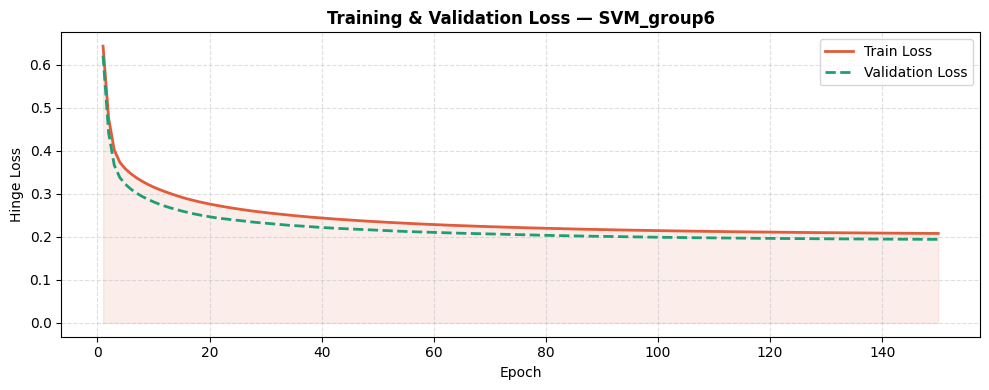

Train loss: 0.6437 → 0.2080
Val   loss: 0.6214 → 0.1943


In [5]:
epochs_ran = len(model.loss_history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, epochs_ran+1), model.loss_history,    color='#E05C3A', lw=2, label='Train Loss')
if model.val_loss_history:
    ax.plot(range(1, epochs_ran+1), model.val_loss_history, color='#1D9E75', lw=2,
            linestyle='--', label='Validation Loss')
ax.fill_between(range(1, epochs_ran+1), model.loss_history, alpha=0.1, color='#E05C3A')
ax.set_xlabel('Epoch'); ax.set_ylabel('Hinge Loss')
ax.set_title('Training & Validation Loss — SVM_group6', fontweight='bold')
ax.legend(); ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()
print(f'Train loss: {model.loss_history[0]:.4f} → {model.loss_history[-1]:.4f}')
if model.val_loss_history:
    print(f'Val   loss: {model.val_loss_history[0]:.4f} → {model.val_loss_history[-1]:.4f}')


## 5. Class DanhGia

In [6]:
class DanhGia:
    @staticmethod
    def confusion_matrix(y_true, y_pred):
        TP = int(np.sum((y_pred==1)&(y_true==1)))
        FP = int(np.sum((y_pred==1)&(y_true==0)))
        TN = int(np.sum((y_pred==0)&(y_true==0)))
        FN = int(np.sum((y_pred==0)&(y_true==1)))
        return TP, FP, TN, FN

    @staticmethod
    def accuracy(y_true, y_pred):  return np.mean(y_true == y_pred)

    @staticmethod
    def precision(TP, FP): return TP/(TP+FP) if (TP+FP)>0 else 0.0

    @staticmethod
    def recall(TP, FN): return TP/(TP+FN) if (TP+FN)>0 else 0.0

    @staticmethod
    def false_positive_rate(FP, TN): return FP/(FP+TN) if (FP+TN)>0 else 0.0

    @staticmethod
    def f1(precision, recall):
        return 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0

    @staticmethod
    def find_best_threshold(y_true, y_scores, metric='f1'):
        """✅ Tìm threshold tốt nhất theo F1 — dùng trên VALIDATION SET."""
        thresholds = np.linspace(y_scores.min(), y_scores.max(), 300)
        best_val, best_t = 0.0, 0.0
        for t in thresholds:
            yp = (y_scores >= t).astype(int)
            TP, FP, TN, FN = DanhGia.confusion_matrix(y_true, yp)
            p = DanhGia.precision(TP, FP); r = DanhGia.recall(TP, FN)
            score = DanhGia.f1(p, r) if metric=='f1' else r
            if score > best_val:
                best_val, best_t = score, t
        return float(best_t), round(best_val, 4)

print('✅ Định nghĩa class DanhGia xong!')


✅ Định nghĩa class DanhGia xong!


## 6. Tìm Threshold Tối Ưu trên Validation Set

> SVM dùng decision boundary tại score=0 mặc định, nhưng ta có thể **dịch chuyển ngưỡng** để tối ưu F1.  
> **✅ Tuning trên val set** — không dùng test set.


In [7]:
y_val_scores = model.decision_function(X_val)
BEST_THRESHOLD, best_f1_val = DanhGia.find_best_threshold(y_val, y_val_scores, metric='f1')
print(f'✅ Threshold tối ưu (val set): {BEST_THRESHOLD:.4f}  |  Val F1 = {best_f1_val:.4f}')
print(f'   (Threshold mặc định SVM = 0.0)')


✅ Threshold tối ưu (val set): -0.3701  |  Val F1 = 0.9426
   (Threshold mặc định SVM = 0.0)


## 7. Đánh giá trên Test Set

In [8]:
y_scores = model.decision_function(X_test)
y_pred   = (y_scores >= BEST_THRESHOLD).astype(int)

TP, FP, TN, FN = DanhGia.confusion_matrix(y_test, y_pred)
acc  = DanhGia.accuracy(y_test, y_pred)
prec = DanhGia.precision(TP, FP)
rec  = DanhGia.recall(TP, FN)
fpr  = DanhGia.false_positive_rate(FP, TN)
f1   = DanhGia.f1(prec, rec)

print('=' * 50)
print('       KẾT QUẢ ĐÁNH GIÁ — SVM_group6')
print('=' * 50)
print(f'  Threshold  : {BEST_THRESHOLD:.4f}')
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall(TPR): {rec:.4f}')
print(f'  FPR        : {fpr:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print('=' * 50)
print()
print('  CONFUSION MATRIX')
print(f'  ┌──────────────────┬───────┬───────┐')
print(f'  │                  │ Pred 0│ Pred 1│')
print(f'  ├──────────────────┼───────┼───────┤')
print(f'  │ Actual 0 (ham)   │  {TN:4d} │  {FP:4d} │')
print(f'  │ Actual 1 (spam)  │  {FN:4d} │  {TP:4d} │')
print(f'  └──────────────────┴───────┴───────┘')
print(f'\n  TP={TP}  TN={TN}  FP={FP} (false alarm)  FN={FN} (spam bị bỏ sót — nguy hiểm)')


       KẾT QUẢ ĐÁNH GIÁ — SVM_group6
  Threshold  : -0.3701
  Accuracy   : 0.9341  (93.41%)
  Precision  : 0.9328
  Recall(TPR): 0.9132
  FPR        : 0.0500
  F1-Score   : 0.9229

  CONFUSION MATRIX
  ┌──────────────────┬───────┬───────┐
  │                  │ Pred 0│ Pred 1│
  ├──────────────────┼───────┼───────┤
  │ Actual 0 (ham)   │   475 │    25 │
  │ Actual 1 (spam)  │    33 │   347 │
  └──────────────────┴───────┴───────┘

  TP=347  TN=475  FP=25 (false alarm)  FN=33 (spam bị bỏ sót — nguy hiểm)


## 8. Visualize — Confusion Matrix + Threshold Analysis

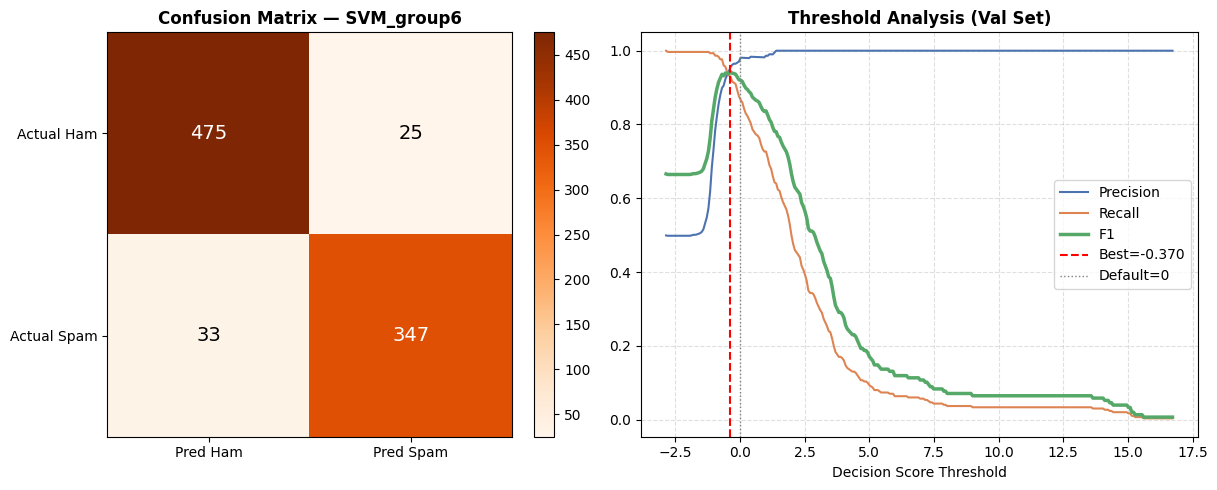

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion Matrix ---
cm = np.array([[TN, FP], [FN, TP]])
im = axes[0].imshow(cm, cmap='Oranges', interpolation='nearest')
axes[0].set_title('Confusion Matrix — SVM_group6', fontweight='bold')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Pred Ham','Pred Spam'])
axes[0].set_yticklabels(['Actual Ham','Actual Spam'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i,j]}', ha='center', va='center', fontsize=14,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# --- Threshold Analysis (val set) ---
ths_range = np.linspace(y_val_scores.min(), y_val_scores.max(), 300)
precs_t, recs_t, f1s_t = [], [], []
for t in ths_range:
    yp = (y_val_scores >= t).astype(int)
    tp, fp, tn, fn = DanhGia.confusion_matrix(y_val, yp)
    p = DanhGia.precision(tp, fp); r = DanhGia.recall(tp, fn)
    precs_t.append(p); recs_t.append(r); f1s_t.append(DanhGia.f1(p, r))

axes[1].plot(ths_range, precs_t, label='Precision', color='#4C72B0')
axes[1].plot(ths_range, recs_t,  label='Recall',    color='#DD8452')
axes[1].plot(ths_range, f1s_t,   label='F1',        color='#55A868', lw=2.5)
axes[1].axvline(BEST_THRESHOLD, color='red', ls='--', label=f'Best={BEST_THRESHOLD:.3f}')
axes[1].axvline(0, color='gray', ls=':', lw=1, label='Default=0')
axes[1].set_xlabel('Decision Score Threshold')
axes[1].set_title('Threshold Analysis (Val Set)', fontweight='bold')
axes[1].legend(); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout(); plt.show()


## 9. So sánh với sklearn LinearSVC

In [10]:
import time
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42, class_weight='balanced')
sklearn_model = CalibratedClassifierCV(base_svm, cv=3)

t0 = time.time()
sklearn_model.fit(X_train, y_train)
print(f'✅ Sklearn LinearSVC train xong! ({time.time()-t0:.2f}s)')


C:\Users\hary0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\hary0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\hary0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\hary0\AppData\Local\Packages\PythonSoftwareFoundation.Python.

✅ Sklearn LinearSVC train xong! (3.11s)


C:\Users\hary0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Metric       |     SVM_group6 |        Sklearn |       Diff
  Accuracy     |         0.9341 |         0.9943 | ▼ 0.0602
  Precision    |         0.9328 |         0.9921 | ▼ 0.0593
  Recall       |         0.9132 |         0.9947 | ▼ 0.0816
  F1-Score     |         0.9229 |         0.9934 | ▼ 0.0706

Sklearn nhỉnh hơn 0.0706 F1 — thử tăng epochs hoặc tune lambda.


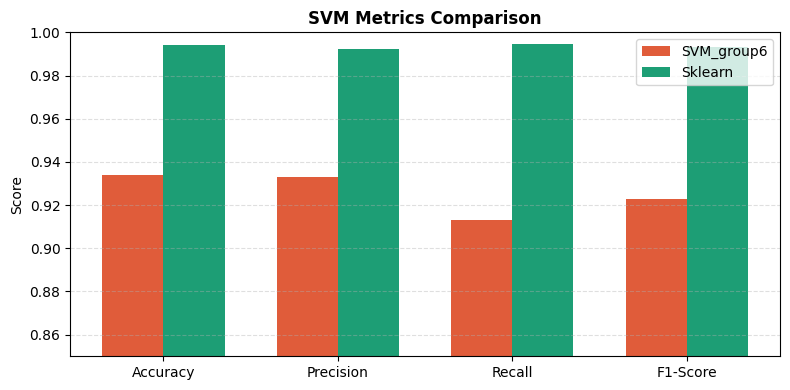

In [11]:
sk_proba     = sklearn_model.predict_proba(X_test)[:, 1]
sk_val_proba = sklearn_model.predict_proba(X_val)[:, 1]

# ✅ Cũng tìm best threshold trên val set cho sklearn
sk_best_t, _ = DanhGia.find_best_threshold(y_val, sk_val_proba)
sk_pred = (sk_proba >= sk_best_t).astype(int)

sk_TP, sk_FP, sk_TN, sk_FN = DanhGia.confusion_matrix(y_test, sk_pred)
sk_acc  = DanhGia.accuracy(y_test, sk_pred)
sk_prec = DanhGia.precision(sk_TP, sk_FP)
sk_rec  = DanhGia.recall(sk_TP, sk_FN)
sk_f1   = DanhGia.f1(sk_prec, sk_rec)

print('=' * 68)
print(f'  {"Metric":<12} | {"SVM_group6":>14} | {"Sklearn":>14} | {"Diff":>10}')
print('=' * 68)
for name, s_val, sk_val in [('Accuracy',acc,sk_acc),('Precision',prec,sk_prec),
                              ('Recall',rec,sk_rec),('F1-Score',f1,sk_f1)]:
    diff = s_val - sk_val
    arrow = '▲' if diff > 0 else ('▼' if diff < 0 else '=')
    print(f'  {name:<12} | {s_val:>14.4f} | {sk_val:>14.4f} | {arrow} {abs(diff):.4f}')
print('=' * 68)

if f1 >= sk_f1 - 0.02:
    print('\n✅ SVM_group6 đạt kết quả tương đương sklearn!')
else:
    print(f'\nSklearn nhỉnh hơn {sk_f1-f1:.4f} F1 — thử tăng epochs hoặc tune lambda.')

# Bar chart
labels_m = ['Accuracy','Precision','Recall','F1-Score']
svm_vals = [acc, prec, rec, f1]
sk_vals  = [sk_acc, sk_prec, sk_rec, sk_f1]
x = np.arange(len(labels_m)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x-w/2, svm_vals, w, label='SVM_group6', color='#E05C3A')
ax.bar(x+w/2, sk_vals,  w, label='Sklearn',    color='#1D9E75')
ax.set_ylabel('Score'); ax.set_title('SVM Metrics Comparison', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels_m)
ax.set_ylim(0.85, 1.0); ax.legend(); ax.grid(axis='y', ls='--', alpha=0.4)
plt.tight_layout(); plt.show()


## 10. ROC Curve + Precision-Recall Curve

In [ ]:
def compute_roc(y_true, y_scores, n=300):
    s_min, s_max = y_scores.min(), y_scores.max()
    norm = (y_scores - s_min) / (s_max - s_min + 1e-9)
    ths  = np.linspace(0, 1, n)
    tprs, fprs = [], []
    for t in ths:
        yp = (norm >= t).astype(int)
        tp = int(np.sum((yp==1)&(y_true==1))); fp = int(np.sum((yp==1)&(y_true==0)))
        tn = int(np.sum((yp==0)&(y_true==0))); fn = int(np.sum((yp==0)&(y_true==1)))
        tprs.append(tp/(tp+fn) if (tp+fn)>0 else 0)
        fprs.append(fp/(fp+tn) if (fp+tn)>0 else 0)
    return np.array(fprs), np.array(tprs)

def compute_pr(y_true, y_scores, n=300):
    s_min, s_max = y_scores.min(), y_scores.max()
    norm = (y_scores - s_min) / (s_max - s_min + 1e-9)
    ths  = np.linspace(0, 1, n)
    ps, rs = [], []
    for t in ths:
        yp = (norm >= t).astype(int)
        tp = int(np.sum((yp==1)&(y_true==1))); fp = int(np.sum((yp==1)&(y_true==0)))
        fn = int(np.sum((yp==0)&(y_true==1)))
        ps.append(tp/(tp+fp) if (tp+fp)>0 else 1.0)
        rs.append(tp/(tp+fn) if (tp+fn)>0 else 0.0)
    return np.array(rs), np.array(ps)

# ✅ Fix: dùng np.trapezoid (NumPy >= 2.0) — np.trapz không tồn tại
def auc_trap(x, y):
    o = np.argsort(x)
    return float(np.trapezoid(y[o], x[o]))

fpr_s,  tpr_s  = compute_roc(y_test, y_scores)
fpr_sk, tpr_sk = compute_roc(y_test, sk_proba)
rec_s,  pre_s  = compute_pr(y_test, y_scores)
rec_sk, pre_sk = compute_pr(y_test, sk_proba)
auc_s   = auc_trap(fpr_s, tpr_s);  auc_sk  = auc_trap(fpr_sk, tpr_sk)
ap_s    = auc_trap(rec_s, pre_s);  ap_sk   = auc_trap(rec_sk, pre_sk)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr_s,  tpr_s,  color='#E05C3A', lw=2.5, label=f'SVM_group6 (AUC={auc_s:.4f})')
axes[0].plot(fpr_sk, tpr_sk, color='#1D9E75', lw=2.5, ls='--', label=f'Sklearn (AUC={auc_sk:.4f})')
axes[0].plot([0,1],[0,1], color='gray', ls=':', lw=1, label='Random')
axes[0].fill_between(fpr_s, tpr_s, alpha=0.08, color='#E05C3A')
axes[0].fill_between(fpr_sk, tpr_sk, alpha=0.08, color='#1D9E75')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(ls='--', alpha=0.4)

# PR Curve
axes[1].plot(rec_s,  pre_s,  color='#E05C3A', lw=2.5, label=f'SVM_group6 (AP={ap_s:.4f})')
axes[1].plot(rec_sk, pre_sk, color='#1D9E75', lw=2.5, ls='--', label=f'Sklearn (AP={ap_sk:.4f})')
axes[1].fill_between(rec_s, pre_s, alpha=0.08, color='#E05C3A')
axes[1].fill_between(rec_sk, pre_sk, alpha=0.08, color='#1D9E75')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(ls='--', alpha=0.4)

plt.tight_layout(); plt.show()
print(f'ROC AUC — SVM_group6: {auc_s:.4f} | Sklearn: {auc_sk:.4f}')
print(f'PR  AUC — SVM_group6: {ap_s:.4f}  | Sklearn: {ap_sk:.4f}')


AttributeError: module 'numpy' has no attribute 'trapz'

## 11. Phân tích trọng số — Top từ quan trọng nhất

In [ ]:
with open(DATA_DIR / 'tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

n_tfidf      = len(vectorizer.get_feature_names_out())
feature_names = list(vectorizer.get_feature_names_out())
w_tfidf       = model.weights[:n_tfidf]

top_spam_idx   = np.argsort(w_tfidf)[-15:][::-1]
top_ham_idx    = np.argsort(w_tfidf)[:15]
top_spam_words = [feature_names[i] for i in top_spam_idx]
top_ham_words  = [feature_names[i] for i in top_ham_idx]
top_spam_sc    = w_tfidf[top_spam_idx]
top_ham_sc     = w_tfidf[top_ham_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(range(15), top_spam_sc, color='#E05C3A', alpha=0.8)
ax1.set_yticks(range(15)); ax1.set_yticklabels(top_spam_words, fontsize=10)
ax1.set_title('Top 15 từ → SPAM\n(weight dương cao)', fontweight='bold')
ax1.set_xlabel('Weight'); ax1.invert_yaxis(); ax1.grid(axis='x', ls='--', alpha=0.5)

ax2.barh(range(15), top_ham_sc, color='#1D9E75', alpha=0.8)
ax2.set_yticks(range(15)); ax2.set_yticklabels(top_ham_words, fontsize=10)
ax2.set_title('Top 15 từ → HAM\n(weight âm thấp)', fontweight='bold')
ax2.set_xlabel('Weight'); ax2.invert_yaxis(); ax2.grid(axis='x', ls='--', alpha=0.5)

plt.suptitle('Phân tích Trọng số SVM — Từ quan trọng nhất', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Lưu model

In [ ]:
import os
os.makedirs('../models', exist_ok=True)
with open('../models/svm_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print('✅ Đã lưu: ../models/svm_model.pkl')


## 13. Demo dự đoán tin nhắn mới

> **✅ Fix bug cũ:** Load `NUMERIC_FEATURES` và `scaler` từ file pkl → đúng số features, đúng thứ tự.


In [ ]:
import re
from scipy.sparse import hstack as sp_hstack, csr_matrix
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Load artifacts đã lưu từ preprocessing
with open(DATA_DIR / 'tfidf_vectorizer.pkl', 'rb') as f: vectorizer     = pickle.load(f)
with open(DATA_DIR / 'numeric_features.pkl', 'rb') as f: NUMERIC_FEATURES = pickle.load(f)
with open(DATA_DIR / 'numeric_scaler.pkl',   'rb') as f: scaler         = pickle.load(f)

stop_words    = set(stopwords.words('english'))
stemmer       = PorterStemmer()
spam_keywords = ['free','win','prize','urgent','call','text','claim','cash','money','offer',
                 'winner','bonus','reward','congratulations','selected']
spam_tags     = ['act now','guaranteed','limited time','buy now','click here','urgent','risk free',
                 'you have won','claim your']
currency_syms = ['$','£','€','¥']

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{10,}\b', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [stemmer.stem(t) for t in text.split() if t not in stop_words and len(t)>1]
    return ' '.join(tokens)

def compute_ALL_numeric(message):
    """Tính đầy đủ tất cả numeric features (giống preprocessing)."""
    msg = str(message)
    cln = msg.lower()
    for pat in [r'http\S+|www\S+|https\S+', r'\S+@\S+', r'\b\d{10,}\b']:
        cln = re.sub(pat, ' ', cln, flags=re.MULTILINE)
    cln = re.sub(r'[^\w\s]', ' ', cln); cln = re.sub(r'\s+', ' ', cln).strip()
    ALL_NUMERIC = ['message_length','word_count','uppercase_words','uppercase_ratio',
                   'special_chars','digit_count','long_words','spam_keywords',
                   'special_ratio','sentence_count','avg_word_length',
                   'exclamation_count','question_count','consecutive_punct',
                   'currency_symbol_count','has_spam_tag','caps_ratio']
    vals = [
        len(msg), len(cln.split()),
        len([w for w in msg.split() if w.isupper() and len(w)>1]),
        len([w for w in msg.split() if w.isupper() and len(w)>1])/(len(cln.split())+1),
        len(re.findall(r'[^\w\s]', msg)), len(re.findall(r'\d', msg)),
        len([w for w in cln.split() if len(w)>6]),
        sum(1 for w in cln.split() if w in spam_keywords),
        len(re.findall(r'[^\w\s]', msg))/(len(msg)+1),
        len(re.findall(r'[.!?]', msg)),
        np.mean([len(w) for w in cln.split()]) if cln.split() else 0,
        msg.count('!'), msg.count('?'),
        len(re.findall(r'([.!?])\1{1,}', msg)),
        sum(msg.count(s) for s in currency_syms),
        int(any(tag in cln for tag in spam_tags)),
        sum(1 for c in msg if c.isupper())/(len(msg)+1)
    ]
    return dict(zip(ALL_NUMERIC, vals))

def predict_message(message):
    """Pipeline đúng: TF-IDF + đúng 8 numeric features + scale → SVM score."""
    processed  = preprocess(message)
    tfidf_vec  = vectorizer.transform([processed])
    all_feats  = compute_ALL_numeric(message)
    # ✅ Lấy đúng features đã chọn lúc train
    num_vals   = np.array([[all_feats[f] for f in NUMERIC_FEATURES]], dtype=np.float32)
    num_scaled = scaler.transform(num_vals)
    combined   = sp_hstack([tfidf_vec, csr_matrix(num_scaled)]).toarray().astype(np.float32)
    score      = model.decision_function(combined)[0]
    label      = 'SPAM' if score >= BEST_THRESHOLD else 'HAM'
    return label, score

# --- Test ---
sample_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim now!",
    "Hey, are you coming to the meeting tomorrow?",
    "URGENT: Your account will be suspended. Verify now at http://fake-site.com",
    "Hi mom, I'll be home late tonight.",
    "Win $1000 cash prize! Call now, limited time offer!",
    "Can you send me the report by Friday?",
]

print(f'{"Tin nhắn":<58} | {"Nhãn":>6} | {"Score":>10}')
print('-'*80)
for msg in sample_messages:
    label, score = predict_message(msg)
    print(f'{msg[:58]:<58} | {label:>6} | {score:>10.4f}')
